# Retail Store Optimization — Group Project
**Course:** Python / Data Analytics  
**Project goal:** Use sales and cost data to recommend inventory levels and an improved product-category mix for a retail store.

> This notebook uses a reproducible **synthetic dataset** so the project runs without private store data. Replace the sample data with your team's store data for a real-world analysis.

**Team members:** Add names here  
**Deliverables:** exploratory analysis, demand estimates, inventory/reorder recommendations, and a constrained category-allocation optimization.

## 1. Business problem and objectives
Retailers need to balance product availability with limited cash and shelf space. Too much stock ties up capital; too little stock can cause lost sales.

We will:
1. Explore category-level sales, margins, and demand.
2. Estimate weekly demand and variability.
3. Calculate a simple reorder point and safety stock for each category.
4. Use linear programming to choose category-level inventory investment under a budget and shelf-capacity limit.
5. Compare the optimized plan with a simple baseline and summarize business implications.

**Assumptions:** category-level aggregation, a 1-week replenishment lead time, normally distributed demand for safety-stock approximation, and expected weekly gross profit as the optimization objective. The model is a decision-support prototype, not a substitute for store-specific validation.

In [1]:
# 2. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
SEED = 42
rng = np.random.default_rng(SEED)

## 3. Create sample retail data
We simulate 12 product categories with different weekly demand, selling price, unit cost, and shelf-space requirements. Change the values or load a CSV in this section when your group has real data.

In [2]:
categories = [
    "Beverages", "Snacks", "Dairy", "Bakery", "Produce", "Personal Care",
    "Cleaning", "Frozen Foods", "Canned Goods", "Pet Supplies", "Stationery", "Household"
]
base = pd.DataFrame({
    "category": categories,
    "avg_weekly_demand": [180, 220, 150, 130, 200, 90, 85, 70, 110, 45, 60, 75],
    "selling_price": [3.5, 2.2, 4.0, 3.0, 2.8, 6.5, 5.8, 5.0, 2.5, 8.0, 2.0, 7.0],
    "unit_cost": [2.0, 1.1, 2.7, 1.5, 1.6, 3.2, 2.8, 3.0, 1.2, 4.5, 0.8, 3.8],
    "shelf_units_per_item": [1.0, 0.7, 1.2, 1.1, 1.0, 0.8, 1.0, 1.4, 0.9, 1.5, 0.6, 1.3]
})

# Generate 26 weeks of observed demand with moderate random variation and a mild seasonal pattern.
weeks = pd.date_range(end=pd.Timestamp.today().normalize(), periods=26, freq="W")
records = []
for i, row in base.iterrows():
    for w, week in enumerate(weeks):
        seasonal = 1 + 0.10 * np.sin(2 * np.pi * w / 26)
        demand = max(0, int(rng.normal(row.avg_weekly_demand * seasonal,
                                       row.avg_weekly_demand * 0.12)))
        records.append({"week": week, "category": row.category, "units_sold": demand})
sales = pd.DataFrame(records)

sales.head()

,week,category,units_sold
0,2026-04-05,Beverages,186
1,2026-04-12,Beverages,161
2,2026-04-19,Beverages,204
3,2026-04-26,Beverages,212
4,2026-05-03,Beverages,152


## 4. Exploratory data analysis
Review demand patterns and estimate category-level average demand and standard deviation from the simulated sales history.

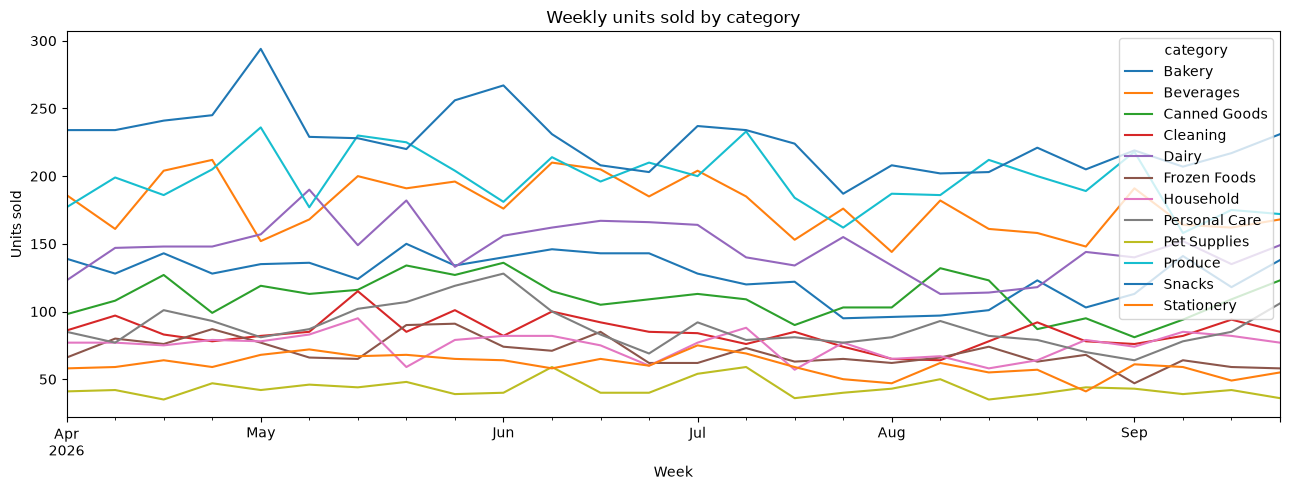

,category,avg_weekly_demand,selling_price,unit_cost,shelf_units_per_item,mean_weekly_demand,sd_weekly_demand,unit_margin,margin_pct,estimated_weekly_revenue,estimated_weekly_gross_profit
5,Personal Care,90,6.50,3.20,0.80,88.42,15.24,3.30,0.51,574.75,291.80
0,Beverages,180,3.50,2.00,1.00,178.54,20.56,1.50,0.43,624.88,267.81
6,Cleaning,85,5.80,2.80,1.00,84.77,10.97,3.00,0.52,491.66,254.31
1,Snacks,220,2.20,1.10,0.70,226.35,22.77,1.10,0.50,497.96,248.98
11,Household,75,7.00,3.80,1.30,75.04,9.67,3.20,0.46,525.27,240.12
4,Produce,200,2.80,1.60,1.00,196.77,21.39,1.20,0.43,550.95,236.12
2,Dairy,150,4.00,2.70,1.20,146.92,19.05,1.30,0.32,587.69,191.00
3,Bakery,130,3.00,1.50,1.10,126.31,16.72,1.50,0.50,378.92,189.46
9,Pet Supplies,45,8.00,4.50,1.50,43.19,6.48,3.50,0.44,345.54,151.17
8,Canned Goods,110,2.50,1.20,0.90,110.31,14.77,1.30,0.52,275.77,143.40


In [3]:
weekly = sales.pivot(index="week", columns="category", values="units_sold")
weekly.plot(figsize=(13, 5), title="Weekly units sold by category")
plt.ylabel("Units sold")
plt.xlabel("Week")
plt.tight_layout()
plt.show()

demand_stats = (sales.groupby("category")["units_sold"]
                .agg(mean_weekly_demand="mean", sd_weekly_demand="std")
                .reset_index())
summary = base.merge(demand_stats, on="category")
summary["unit_margin"] = summary["selling_price"] - summary["unit_cost"]
summary["margin_pct"] = summary["unit_margin"] / summary["selling_price"]
summary["estimated_weekly_revenue"] = summary["mean_weekly_demand"] * summary["selling_price"]
summary["estimated_weekly_gross_profit"] = summary["mean_weekly_demand"] * summary["unit_margin"]
summary.sort_values("estimated_weekly_gross_profit", ascending=False)

## 5. Inventory policy: safety stock and reorder point
For a target service level of 95%, use a z-score of approximately 1.645. With a one-week lead time:
- Safety stock = z × weekly demand standard deviation × √(lead time)
- Reorder point = average weekly demand × lead time + safety stock

This is a simplified periodic-demand model. Real implementations should account for actual supplier lead times, pack sizes, perishability, and promotions.

In [4]:
SERVICE_LEVEL_Z = 1.645
LEAD_TIME_WEEKS = 1

summary["safety_stock_units"] = np.ceil(
    SERVICE_LEVEL_Z * summary["sd_weekly_demand"] * np.sqrt(LEAD_TIME_WEEKS)
).astype(int)
summary["reorder_point_units"] = np.ceil(
    summary["mean_weekly_demand"] * LEAD_TIME_WEEKS + summary["safety_stock_units"]
).astype(int)

summary[["category", "mean_weekly_demand", "sd_weekly_demand",
         "safety_stock_units", "reorder_point_units"]]

,category,mean_weekly_demand,sd_weekly_demand,safety_stock_units,reorder_point_units
0,Beverages,178.54,20.56,34,213
1,Snacks,226.35,22.77,38,265
2,Dairy,146.92,19.05,32,179
3,Bakery,126.31,16.72,28,155
4,Produce,196.77,21.39,36,233
5,Personal Care,88.42,15.24,26,115
6,Cleaning,84.77,10.97,19,104
7,Frozen Foods,69.77,10.59,18,88
8,Canned Goods,110.31,14.77,25,136
9,Pet Supplies,43.19,6.48,11,55


## 6. Optimize category inventory investment
We allocate a limited inventory budget across categories. Let `xᵢ` be the number of units of category *i* to stock for the planning horizon.

**Objective:** maximize expected gross profit from planned stock, using estimated weekly demand and unit margin.  
**Constraints:** total purchasing cost must stay within the budget, and total shelf-space units must stay within capacity. Each category has a minimum stock equal to estimated average weekly demand and a maximum of 1.8 weeks of demand.

The linear program is a simplified assortment/inventory allocation model. It does not model substitution, replenishment timing, or lost-sales curves.

In [5]:
# Editable planning constraints
INVENTORY_BUDGET = 6500.0       # currency units
SHELF_CAPACITY = 2600.0         # shelf-space units
PLANNING_WEEKS = 1.0

# Decision variable bounds: minimum 0.5 weeks, maximum 1.8 weeks of expected demand
lower = np.maximum(1, np.floor(summary["mean_weekly_demand"] * 0.5)).astype(int)
upper = np.ceil(summary["mean_weekly_demand"] * 1.8).astype(int)

# scipy.optimize.linprog minimizes, so negate profit coefficients.
profit_per_unit = summary["unit_margin"].to_numpy()
cost_per_unit = summary["unit_cost"].to_numpy()
space_per_unit = summary["shelf_units_per_item"].to_numpy()

A = np.vstack([cost_per_unit, space_per_unit])
b = np.array([INVENTORY_BUDGET, SHELF_CAPACITY])
bounds = list(zip(lower, upper))

result = linprog(c=-profit_per_unit, A_ub=A, b_ub=b,
                 bounds=bounds, method="highs")

if not result.success:
    raise RuntimeError(f"Optimization failed: {result.message}")

summary["optimized_stock_units"] = np.floor(result.x).astype(int)
summary["optimized_purchase_cost"] = summary["optimized_stock_units"] * summary["unit_cost"]
summary["optimized_expected_gross_profit"] = (
    summary["optimized_stock_units"] * summary["unit_margin"]
)
summary["optimized_shelf_space"] = (
    summary["optimized_stock_units"] * summary["shelf_units_per_item"]
)

print("Solver status:", result.message)
print(f"Total planned purchase cost: {summary.optimized_purchase_cost.sum():,.2f}")
print(f"Total shelf space used: {summary.optimized_shelf_space.sum():,.1f}")
print(f"Estimated gross profit on planned stock: {summary.optimized_expected_gross_profit.sum():,.2f}")

Solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Total planned purchase cost: 5,230.50
Total shelf space used: 2,527.1
Estimated gross profit on planned stock: 4,381.00


## 7. Review the recommended allocation
Compare optimized stock with one week of average demand. Positive values indicate additional buffer stock; negative values indicate a leaner plan than the baseline.

In [6]:
summary["baseline_stock_units"] = np.ceil(summary["mean_weekly_demand"]).astype(int)
summary["stock_change_vs_baseline"] = (
    summary["optimized_stock_units"] - summary["baseline_stock_units"]
)
recommendations = summary[[
    "category", "mean_weekly_demand", "baseline_stock_units",
    "optimized_stock_units", "stock_change_vs_baseline",
    "optimized_purchase_cost", "optimized_expected_gross_profit"
]].sort_values("optimized_expected_gross_profit", ascending=False)

recommendations

,category,mean_weekly_demand,baseline_stock_units,optimized_stock_units,stock_change_vs_baseline,optimized_purchase_cost,optimized_expected_gross_profit
5,Personal Care,88.42,89,160,71,512.00,528.00
0,Beverages,178.54,179,322,143,644.00,483.00
6,Cleaning,84.77,85,153,68,428.40,459.00
1,Snacks,226.35,227,408,181,448.80,448.80
11,Household,75.04,76,136,60,516.80,435.20
4,Produce,196.77,197,355,158,568.00,426.00
2,Dairy,146.92,147,265,118,715.50,344.50
3,Bakery,126.31,127,228,101,342.00,342.00
9,Pet Supplies,43.19,44,78,34,351.00,273.00
8,Canned Goods,110.31,111,199,88,238.80,258.70


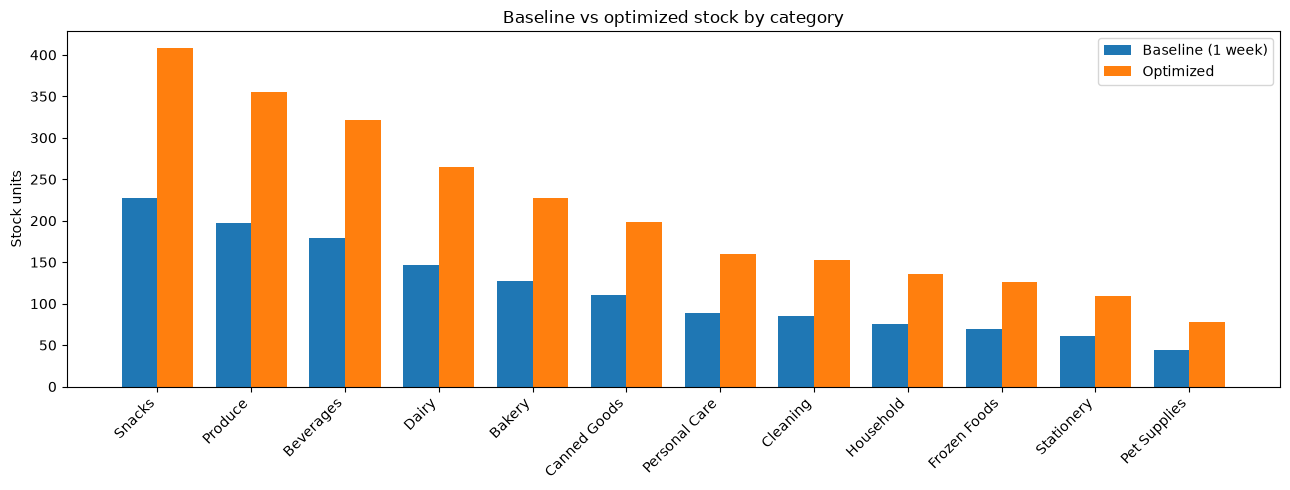

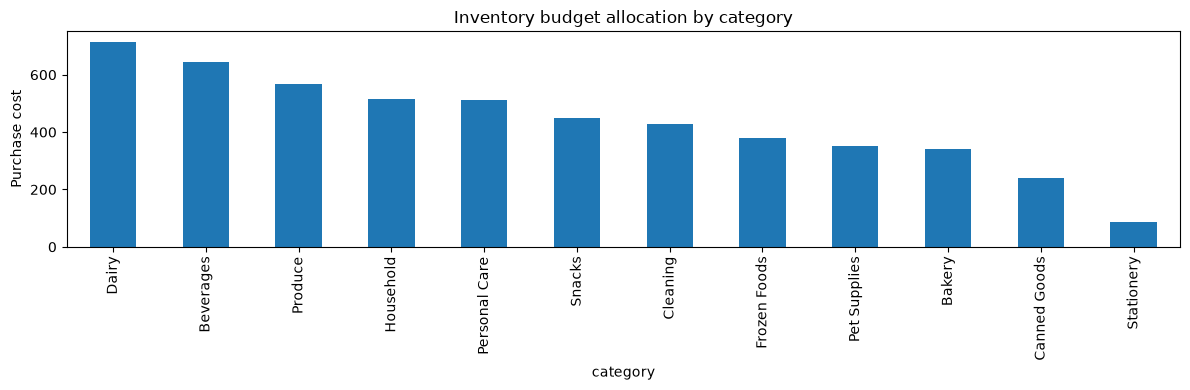

In [7]:
# Visual comparison of baseline and optimized stock
plot_data = recommendations.sort_values("optimized_stock_units", ascending=False)
x = np.arange(len(plot_data))
width = 0.38
plt.figure(figsize=(13, 5))
plt.bar(x - width/2, plot_data["baseline_stock_units"], width, label="Baseline (1 week)")
plt.bar(x + width/2, plot_data["optimized_stock_units"], width, label="Optimized")
plt.xticks(x, plot_data["category"], rotation=45, ha="right")
plt.ylabel("Stock units")
plt.title("Baseline vs optimized stock by category")
plt.legend()
plt.tight_layout()
plt.show()

summary.sort_values("optimized_purchase_cost", ascending=False).plot(
    x="category", y="optimized_purchase_cost", kind="bar", figsize=(12, 4),
    legend=False, title="Inventory budget allocation by category"
)
plt.ylabel("Purchase cost")
plt.tight_layout()
plt.show()

## 8. Key findings and project conclusion
Use the generated tables and charts to write your group's findings. Suggested points to discuss:

- Which categories have the highest estimated weekly gross profit?
- Which categories have the greatest demand variability and therefore need more safety stock?
- Does the optimized plan use the full budget or shelf capacity? Which constraint is binding?
- What trade-offs does the optimized allocation make versus stocking one average week of demand?
- What additional data would improve the model (actual on-hand inventory, supplier lead times, stockout records, promotions, expiry dates, and store-level shelf dimensions)?

**Conclusion template:**  
“Using 26 weeks of category-level demand, our model recommends allocating inventory across categories while respecting a purchase budget of [budget] and shelf capacity of [capacity]. The plan prioritizes categories based on expected gross margin, while the reorder-point analysis provides a basic buffer against demand variation. The recommendations should be validated against actual store operations before implementation.”

## 9. Optional extension: load your team's real sales data
Prepare a CSV with columns `week`, `category`, and `units_sold`. Then replace the synthetic `sales` creation cell with:

```python
sales = pd.read_csv("your_retail_sales.csv", parse_dates=["week"])
```

Update the `base` table with each category's selling price, unit cost, and shelf-space requirement. Ensure the category names match exactly. For a stronger group project, test several budgets/service levels and compare outcomes.